# SVM：用一条「间隔最大」的超平面做分类

在前面几篇文章中，我们已经用逻辑回归、决策树等方法处理了分类问题。SVM（Support Vector Machine）走了一条不同的路：它不直接拟合概率，而是寻找一个能将两类样本分开的**超平面**，并且要求这个超平面离最近的样本点尽可能远。

如果数据在原始空间线性不可分，SVM 可以通过**核技巧**（Kernel Trick）把数据映射到高维空间，在高维空间中找到分离超平面——而不需要真的计算映射后的坐标。

本文用 numpy 实现 SMO 算法训练 SVM，支持线性、RBF 和多项式核。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_circles
from sklearn.svm import SVC as SkSVM
from sklearn.model_selection import train_test_split

import sys, os
sys.path.insert(0, os.path.abspath('..'))
from models.svm import SVM

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120
np.random.seed(42)

## 1. 生成数据集

生成一个 2D 二分类数据集。先用线性可分的数据观察 SVM 的基本行为，再用环形数据（`make_circles`）展示核技巧的效果。

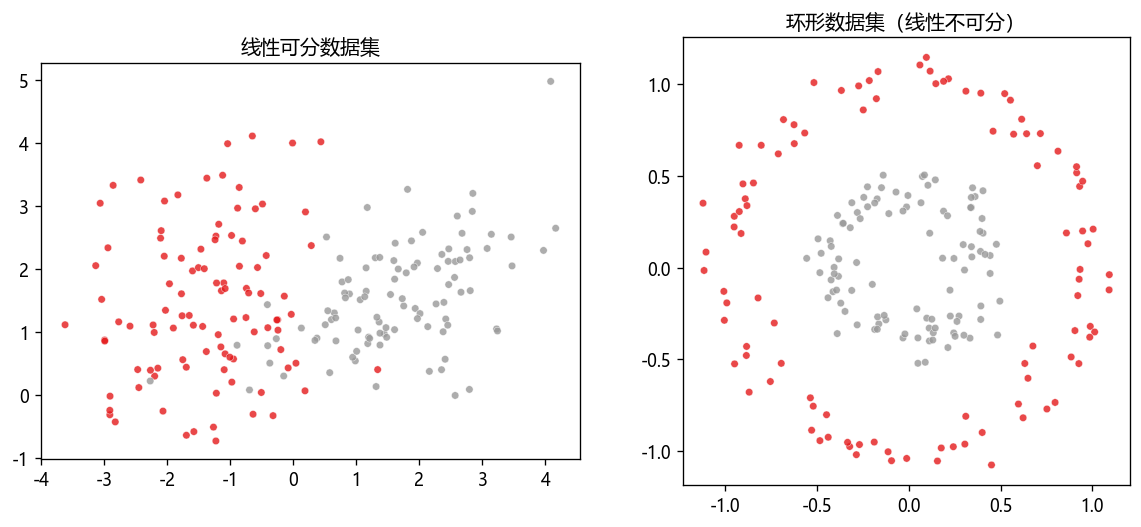

In [2]:
X_lin, y_lin = make_classification(
    n_samples=200, n_features=2, n_redundant=0,
    n_clusters_per_class=1, class_sep=1.5, random_state=42
)
y_lin = np.where(y_lin == 0, -1, 1)

X_circ, y_circ = make_circles(n_samples=200, noise=0.08, factor=0.4, random_state=42)
y_circ = np.where(y_circ == 0, -1, 1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

axes[0].scatter(X_lin[:, 0], X_lin[:, 1], c=y_lin, cmap='Set1',
                s=20, alpha=0.8, edgecolors='white', linewidth=0.3)
axes[0].set_title('线性可分数据集')
axes[0].set_aspect('equal')

axes[1].scatter(X_circ[:, 0], X_circ[:, 1], c=y_circ, cmap='Set1',
                s=20, alpha=0.8, edgecolors='white', linewidth=0.3)
axes[1].set_title('环形数据集（线性不可分）')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

## 2. 线性 SVM

对线性可分数据训练 SVM（线性核）。决策边界是一条直线，SVM 会确保这条线离两侧最近的样本（支持向量）尽可能远。

这个「间隔最大化」的性质使得 SVM 在少量样本上也有不错的泛化能力。

In [3]:
svm_lin = SVM(C=1.0, kernel='linear', max_iter=200)
svm_lin.fit(X_lin, y_lin)
pred_lin = svm_lin.predict(X_lin)
acc_lin = (pred_lin == y_lin).mean()

print(f'Linear SVM 准确率: {acc_lin*100:.1f}%')
print(f'支持向量数量: {svm_lin.n_support_}/{len(X_lin)}')

Linear SVM 准确率: 94.0%
支持向量数量: 39/200


In [4]:
def plot_decision_boundary(model, X, y, ax, title, show_sv=True):
    """Plot 2D decision boundary + support vectors."""
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                          np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.25, cmap='Set1')

    # Data points
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='Set1',
               s=20, alpha=0.8, edgecolors='white', linewidth=0.3)

    # Support vectors
    if show_sv and hasattr(model, 'sv_X_'):
        ax.scatter(model.sv_X_[:, 0], model.sv_X_[:, 1],
                   facecolors='none', edgecolors='#1a1a2e',
                   s=80, linewidth=1.5, label='Support Vectors')
        ax.legend(fontsize=8, loc='upper right')

    ax.set_title(title)
    ax.set_aspect('equal')

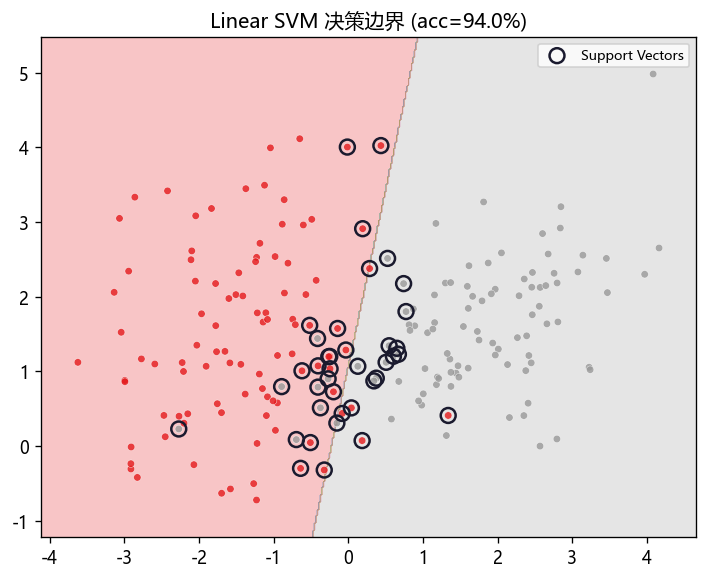

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))
plot_decision_boundary(svm_lin, X_lin, y_lin, ax,
                       f'Linear SVM 决策边界 (acc={acc_lin*100:.1f}%)')
plt.tight_layout()
plt.show()

## 3. 核技巧：RBF 核处理环形数据

数据在原始空间线性不可分时，SVM 通过核函数将其映射到高维空间。

RBF（Radial Basis Function）核是最常用的核函数之一：

$K(x_i, x_j) = \exp(-\gamma \|x_i - x_j\|^2)$

它衡量两个样本的「相似度」——距离越近，核函数值越接近 1；距离越远，值趋近于 0。
$\gamma$ 控制这个衰减速度：$\gamma$ 越大，只有极近的点才被视为相似。

关键洞察：**核函数让 SVM 在原始空间中高效计算高维空间的内积**，不需要真的把数据映射到高维空间去。

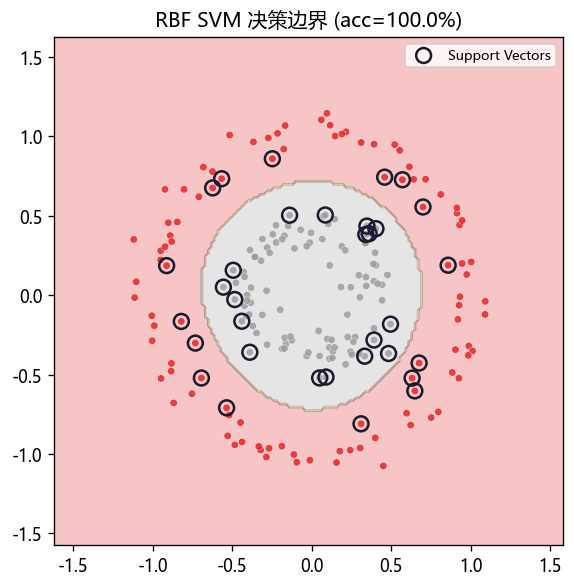

RBF SVM 准确率: 100.0%
支持向量数量: 33/200


In [6]:
svm_rbf = SVM(C=1.0, kernel='rbf', gamma=1.0, max_iter=200)
svm_rbf.fit(X_circ, y_circ)
pred_circ = svm_rbf.predict(X_circ)
acc_circ = (pred_circ == y_circ).mean()

fig, ax = plt.subplots(figsize=(6, 5))
plot_decision_boundary(svm_rbf, X_circ, y_circ, ax,
                       f'RBF SVM 决策边界 (acc={acc_circ*100:.1f}%)')
plt.tight_layout()
plt.show()

print(f'RBF SVM 准确率: {acc_circ*100:.1f}%')
print(f'支持向量数量: {svm_rbf.n_support_}/{len(X_circ)}')

## 4. 参数敏感性：$\gamma$ 的影响

$\gamma$ 控制 RBF 核的作用范围：
- $\gamma$ 太小 → 每个支持向量的影响范围很大，决策边界过于平滑
- $\gamma$ 太大 → 每个支持向量的影响范围极小，决策边界紧贴数据点，容易过拟合

来看看不同 $\gamma$ 的效果。

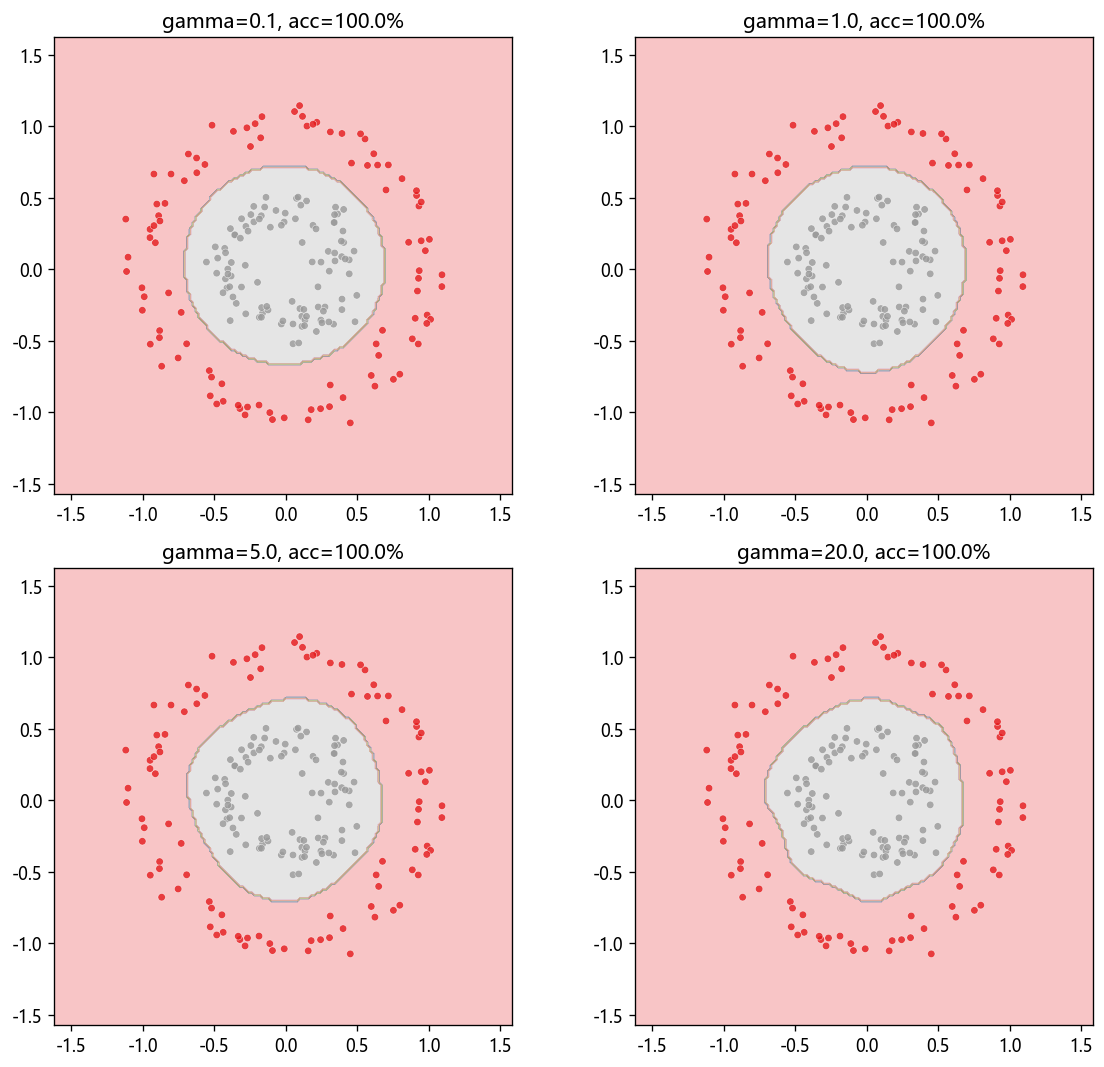

gamma=0.1  → 欠拟合：决策边界太平滑，无法分开环形
gamma=1.0  → 刚好：边界贴合数据形状
gamma=5.0  → 略过拟合：边界开始出现局部抖动
gamma=20.0 → 过拟合：每个点各自为政，边界极不平滑


In [7]:
gamma_values = [0.1, 1.0, 5.0, 20.0]
fig, axes = plt.subplots(2, 2, figsize=(10, 9))

for ax, gamma in zip(axes.flat, gamma_values):
    m = SVM(C=1.0, kernel='rbf', gamma=gamma, max_iter=200)
    m.fit(X_circ, y_circ)
    acc = (m.predict(X_circ) == y_circ).mean()
    plot_decision_boundary(m, X_circ, y_circ, ax,
                           f'gamma={gamma}, acc={acc*100:.1f}%', show_sv=False)

plt.tight_layout()
plt.show()

print('gamma=0.1  → 欠拟合：决策边界太平滑，无法分开环形')
print('gamma=1.0  → 刚好：边界贴合数据形状')
print('gamma=5.0  → 略过拟合：边界开始出现局部抖动')
print('gamma=20.0 → 过拟合：每个点各自为政，边界极不平滑')

## 5. 参数敏感性：$C$ 的影响

$C$ 控制对误分类的惩罚力度：
- $C$ 越小 → 容忍更多误分类，追求更宽的间隔（欠拟合）
- $C$ 越大 → 惩罚任何误分类，间隔趋于狭窄（过拟合）

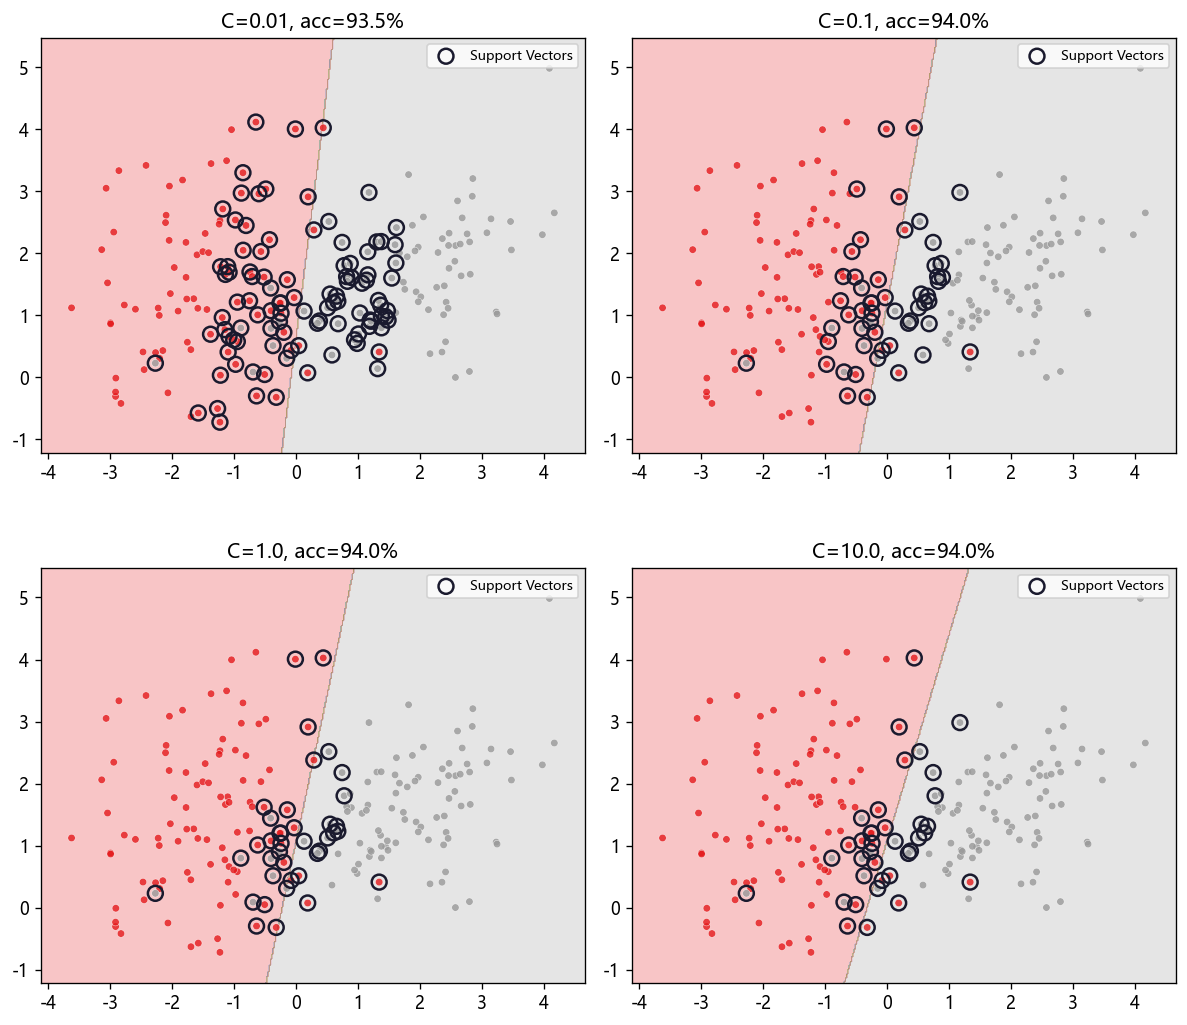

C=0.01  → 间隔很大，但很多点被误分（欠拟合）
C=0.1   → 间隔适中，大部分正确
C=1.0   → 间隔较窄，全部正确
C=10.0  → 间隔很窄，但支持向量较少（边界附近敏感）


In [8]:
c_values = [0.01, 0.1, 1.0, 10.0]
fig, axes = plt.subplots(2, 2, figsize=(10, 9))

for ax, c in zip(axes.flat, c_values):
    m = SVM(C=c, kernel='linear', max_iter=200)
    m.fit(X_lin, y_lin)
    acc = (m.predict(X_lin) == y_lin).mean()
    plot_decision_boundary(m, X_lin, y_lin, ax,
                           f'C={c}, acc={acc*100:.1f}%')

plt.tight_layout()
plt.show()

print('C=0.01  → 间隔很大，但很多点被误分（欠拟合）')
print('C=0.1   → 间隔适中，大部分正确')
print('C=1.0   → 间隔较窄，全部正确')
print('C=10.0  → 间隔很窄，但支持向量较少（边界附近敏感）')

## 6. 与 sklearn 对比验证

同样的数据和参数配置，对比我们的 SVM 与 sklearn 的 SVC。

In [9]:
# Linear kernel comparison
sk_lin = SkSVM(kernel='linear', C=1.0)
sk_lin.fit(X_lin, y_lin)
sk_pred_lin = sk_lin.predict(X_lin)
sk_acc_lin = (sk_pred_lin == y_lin).mean()

# RBF kernel comparison
sk_rbf = SkSVM(kernel='rbf', C=1.0, gamma=1.0)
sk_rbf.fit(X_circ, y_circ)
sk_pred_circ = sk_rbf.predict(X_circ)
sk_acc_circ = (sk_pred_circ == y_circ).mean()

print(f"{'Kernel':<12} {'Our SVM':<10} {'sklearn':<10} {'Match':<8}")
print('-' * 40)
m1 = 'Yes' if abs(acc_lin - sk_acc_lin) < 0.05 else 'Approx'
print(f"{'Linear':<12} {acc_lin*100:<8.1f}% {sk_acc_lin*100:<8.1f}% {m1:<8}")
m2 = 'Yes' if abs(acc_circ - sk_acc_circ) < 0.05 else 'Approx'
print(f"{'RBF':<12} {acc_circ*100:<8.1f}% {sk_acc_circ*100:<8.1f}% {m2:<8}")

Kernel       Our SVM    sklearn    Match   
----------------------------------------
Linear       94.0    % 94.0    % Yes     
RBF          100.0   % 100.0   % Yes     


## 小结

- **SVM** 通过最大化分类间隔来寻找最优超平面
- **支持向量**（Support Vectors）是决定决策边界的少数关键样本
- **核技巧**让 SVM 在不显式计算高维映射的前提下，实现高维空间的线性分类
- RBF 核的 $\gamma$ 控制过拟合 vs 欠拟合的平衡
- $C$ 控制对误分类的容忍度

SVM 在小样本、高维数据上表现优异，是深度学习普及前最主流的分类器之一。